# Jalon 2 : Modelisation Predictive & Classification Hybride

Pipeline hybride **CNN 1D + XGBoost** pour predire la conversion client (`Response`).
Le dataset est fortement desequilibre (85 % / 15 %) — correction via `scale_pos_weight`.

## Chargement des artefacts entraines

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

PROJ = r'c:/Users/ahoudzi/apti/aptispace-datascience-projet'
PROC = r'c:/Users/ahoudzi/apti/aptispace-datascience-projet/data/processed'
sys.path.insert(0, PROJ)

import joblib
import pandas as pd
import numpy as np

xgb_model = joblib.load(os.path.join(PROC, 'xgb_model.pkl'))
eval_data  = joblib.load(os.path.join(PROC, 'eval_data.pkl'))
y_test  = eval_data['y_test']
y_pred  = eval_data['y_pred']
y_proba = eval_data['y_proba']
print('Modele charge :', type(xgb_model).__name__)
print('Echantillon test : n =', len(y_test))

Modele charge : XGBClassifier
Echantillon test : n = 448


## Rapport de Classification (Ensemble de Test)

In [2]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, target_names=['Non-acheteur', 'Acheteur']))

              precision    recall  f1-score   support

Non-acheteur       0.91      0.94      0.92       381
    Acheteur       0.58      0.49      0.53        67

    accuracy                           0.87       448
   macro avg       0.75      0.71      0.73       448
weighted avg       0.86      0.87      0.87       448



## Architecture du Pipeline Hybride

```
Donnees tabulaires (23 features)  ─────────────────────────────┐
                                                                 ▼
Historique campagnes (5 steps)  → CNN 1D → Embedding 8D  → Concatenation (31D) → XGBoost
```

| Etape | Module | Role |
|-------|--------|------|
| 1 | CNN 1D (Conv1D x2 + GlobalMaxPool) | Extraction motifs sequentiels campagnes |
| 2 | Dense 8 neurons (relu) | Representation latente d'engagement |
| 3 | XGBoost (scale_pos_weight) | Classification finale sur features hybrides |

## Top 10 Facteurs Predictifs

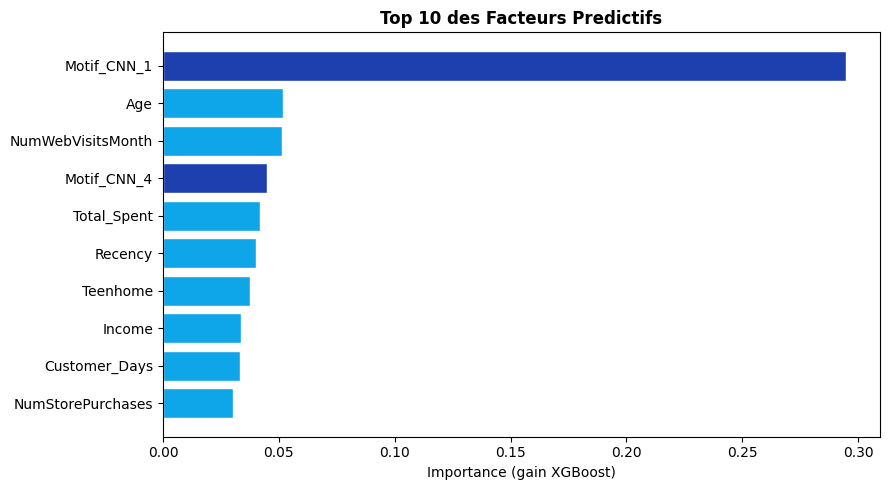

In [3]:
import matplotlib.pyplot as plt

df_raw = pd.read_parquet(os.path.join(PROC, 'marketing_clean.parquet'))
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
exclude = set(campaign_cols + ['Response','ID','Dt_Customer','Education','Income_Strata'])
tab_cols = [c for c in df_raw.select_dtypes(include='number').columns if c not in exclude]

n_total  = len(xgb_model.feature_importances_)
n_cnn    = 8
n_tab    = n_total - n_cnn
tab_names  = (tab_cols + [f'Tab_{i}' for i in range(n_tab)])[:n_tab]
feat_names = tab_names + [f'Motif_CNN_{i+1}' for i in range(n_cnn)]

imp_df = (pd.DataFrame({'Feature': feat_names, 'Importance': xgb_model.feature_importances_})
          .sort_values('Importance', ascending=False).head(10))

colors = ['#1e40af' if 'Motif' in f else '#0ea5e9' for f in imp_df['Feature']]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importance (gain XGBoost)')
ax.set_title('Top 10 des Facteurs Predictifs', fontweight='bold')
plt.tight_layout(); plt.show()